In [9]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap
from module import FlowMatchingModel

In [16]:
class BottleneckExtractor:
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
        self.model.to(self.device)
        self.model.eval()
        
        self.bottleneck_features = []
        self.model.scalar_field.bottleneck.register_forward_hook(self._hook_fn)
        
    def _hook_fn(self, module, input, output):
        pooled = torch.mean(output, dim=[2, 3])  # Global average pooling
        self.bottleneck_features.append(pooled.detach().cpu())
    
    def extract_features(self, total_mass_maps, star_maps, gas_maps, astro_params, batch_size=25):
        """Extract features in small batches to avoid memory issues"""
        all_batch_features = []
        n_samples = len(total_mass_maps)
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            # Clear previous features
            self.bottleneck_features = []
            
            # Get batch slices
            batch_total = total_mass_maps[i:end_idx]
            batch_star = star_maps[i:end_idx] 
            batch_gas = gas_maps[i:end_idx]
            
            # Handle astro_params indexing
            astro_start = i // 15
            astro_end = min((end_idx + 14) // 15, len(astro_params))
            batch_astro = astro_params[astro_start:astro_end]
            
            # Convert to tensors
            total_mass = torch.FloatTensor(batch_total).unsqueeze(1).to(self.device)
            target_maps = torch.stack([
                torch.FloatTensor(batch_star),
                torch.FloatTensor(batch_gas)
            ], dim=1).to(self.device)
            astro_params_tensor = torch.FloatTensor(batch_astro).to(self.device)
            
            # Create forward pass
            current_batch_size = total_mass.size(0)
            t = torch.rand(current_batch_size, device=self.device)
            
            x0 = total_mass.expand(-1, 2, -1, -1)
            x1 = target_maps
            t_expanded = t.view(-1, 1, 1, 1)
            x_t = (1 - t_expanded) * x0 + t_expanded * x1
            
            # Handle astro_params batch size matching
            if astro_params_tensor.size(0) != current_batch_size:
                repeat_factor = (current_batch_size + astro_params_tensor.size(0) - 1) // astro_params_tensor.size(0)
                astro_params_tensor = astro_params_tensor.repeat(repeat_factor, 1)[:current_batch_size]
            
            condition_param = torch.cat([t.unsqueeze(1), astro_params_tensor], dim=1)
            
            with torch.no_grad():
                _ = self.model.scalar_field(x_t, condition_param, total_mass, target_maps)
            
            # Collect batch features
            if self.bottleneck_features:
                batch_features = torch.cat(self.bottleneck_features, dim=0).cpu().numpy()
                all_batch_features.append(batch_features)
            
            # Clear GPU memory immediately
            del total_mass, target_maps, astro_params_tensor, x_t, condition_param
            torch.cuda.empty_cache()
        
        # Combine all batches
        if all_batch_features:
            return np.vstack(all_batch_features)
        return np.array([])

def load_model_data(model_name, n_samples=500, data_dir="/n/netscratch/iaifi_lab/Lab/msliu/CMD/data"):
    """Load and normalize data following training pattern exactly"""
    
    # Load full datasets
    total_mass = np.load(f'{data_dir}/{model_name}/Maps_Mtot_{model_name}_LH_z=0.00.npy')
    star_maps = np.load(f'{data_dir}/{model_name}/Maps_Mstar_{model_name}_LH_z=0.00.npy')
    gas_maps = np.load(f'{data_dir}/{model_name}/Maps_Mgas_{model_name}_LH_z=0.00.npy')
    params = np.loadtxt(f'{data_dir}/{model_name}/params_LH_{model_name}.txt')
    
    # Apply log1p transformation (training pattern)
    total_mass_log = np.log1p(total_mass)
    star_maps_log = np.log1p(star_maps)
    gas_maps_log = np.log1p(gas_maps)
    
    # Compute normalization from full dataset
    tot_mean, tot_std = total_mass_log.mean(), total_mass_log.std()
    star_mean, star_std = star_maps_log.mean(), star_maps_log.std()
    gas_mean, gas_std = gas_maps_log.mean(), gas_maps_log.std()
    
    # Sample and normalize
    if len(total_mass_log) > n_samples:
        indices = np.random.choice(len(total_mass_log), n_samples, replace=False)
        total_mass = (total_mass_log[indices] - tot_mean) / tot_std
        star_maps = (star_maps_log[indices] - star_mean) / star_std
        gas_maps = (gas_maps_log[indices] - gas_mean) / gas_std
        cosmo_params = params[indices//15, :2]  
        astro_params = params[indices//15, 2:]  
    else:
        print("More samples than available requested")
    
    return total_mass, star_maps, gas_maps, cosmo_params, astro_params

In [33]:

# Configuration
checkpoint_path = 'lightning_logs/FM_all/checkpoints/best-model-epoch=88-val_loss=0.023915.ckpt'
cosmological_models = ['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid']
n_samples_per_model = 5000  # Reduced further for memory safety

print("Extracting bottleneck features...")

# Load model once
extractor = BottleneckExtractor(checkpoint_path)

# Collect features from all models
all_features = []
all_labels = []
all_astro_params = []

for model_name in cosmological_models:
    print(f"Processing {model_name}...")
    
    # Load data
    total_mass, star_maps, gas_maps, cosmo_params, astro_params = load_model_data(
        model_name, n_samples_per_model
    )
    
    # Extract features in small batches
    features = extractor.extract_features(
        total_mass, star_maps, gas_maps, cosmo_params, batch_size=25
    )
    
    if len(features) > 0:
        all_features.append(features)
        all_labels.extend([model_name] * len(features))
        print(f"  Extracted {len(features)} features")

    all_astro_params.append(astro_params)
    
    # Clear memory between models
    torch.cuda.empty_cache()
    print(f"  Memory cleared after {model_name}")

# Combine and reduce dimensions
X = np.vstack(all_features)
print(f"Total features: {X.shape}")

Extracting bottleneck features...
Processing IllustrisTNG...
  Extracted 5000 features
  Memory cleared after IllustrisTNG
Processing EAGLE...
  Extracted 5000 features
  Memory cleared after EAGLE
Processing SIMBA...
  Extracted 5000 features
  Memory cleared after SIMBA
Processing Astrid...
  Extracted 5000 features
  Memory cleared after Astrid
Total features: (20000, 512)


In [ ]:
# UMAP with simple, robust parameters
print("Running UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X)

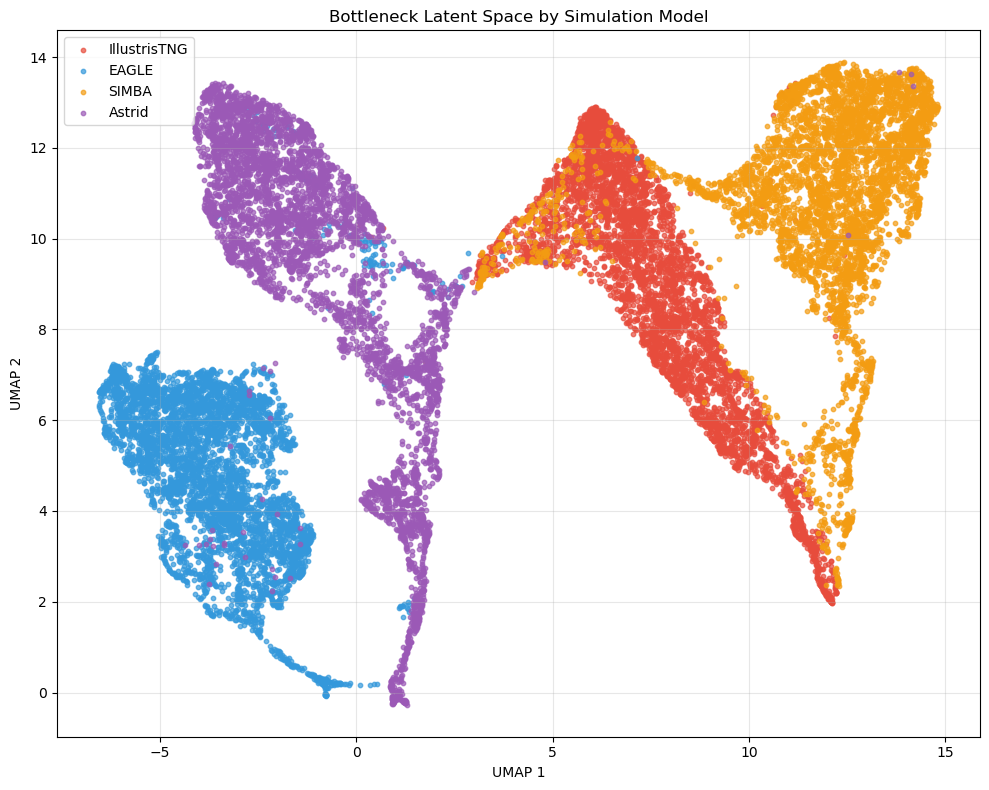

Visualization saved. Total samples: 20000


In [23]:
# Visualize
plt.figure(figsize=(10, 8))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']

for i, model_name in enumerate(cosmological_models):
    mask = [label == model_name for label in all_labels]
    plt.scatter(embedding[mask, 0], embedding[mask, 1], 
               c=colors[i], label=model_name, alpha=0.7, s=10)

plt.title('Bottleneck Latent Space by Simulation Model')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("umap_visualisation.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization saved. Total samples: {len(embedding)}")


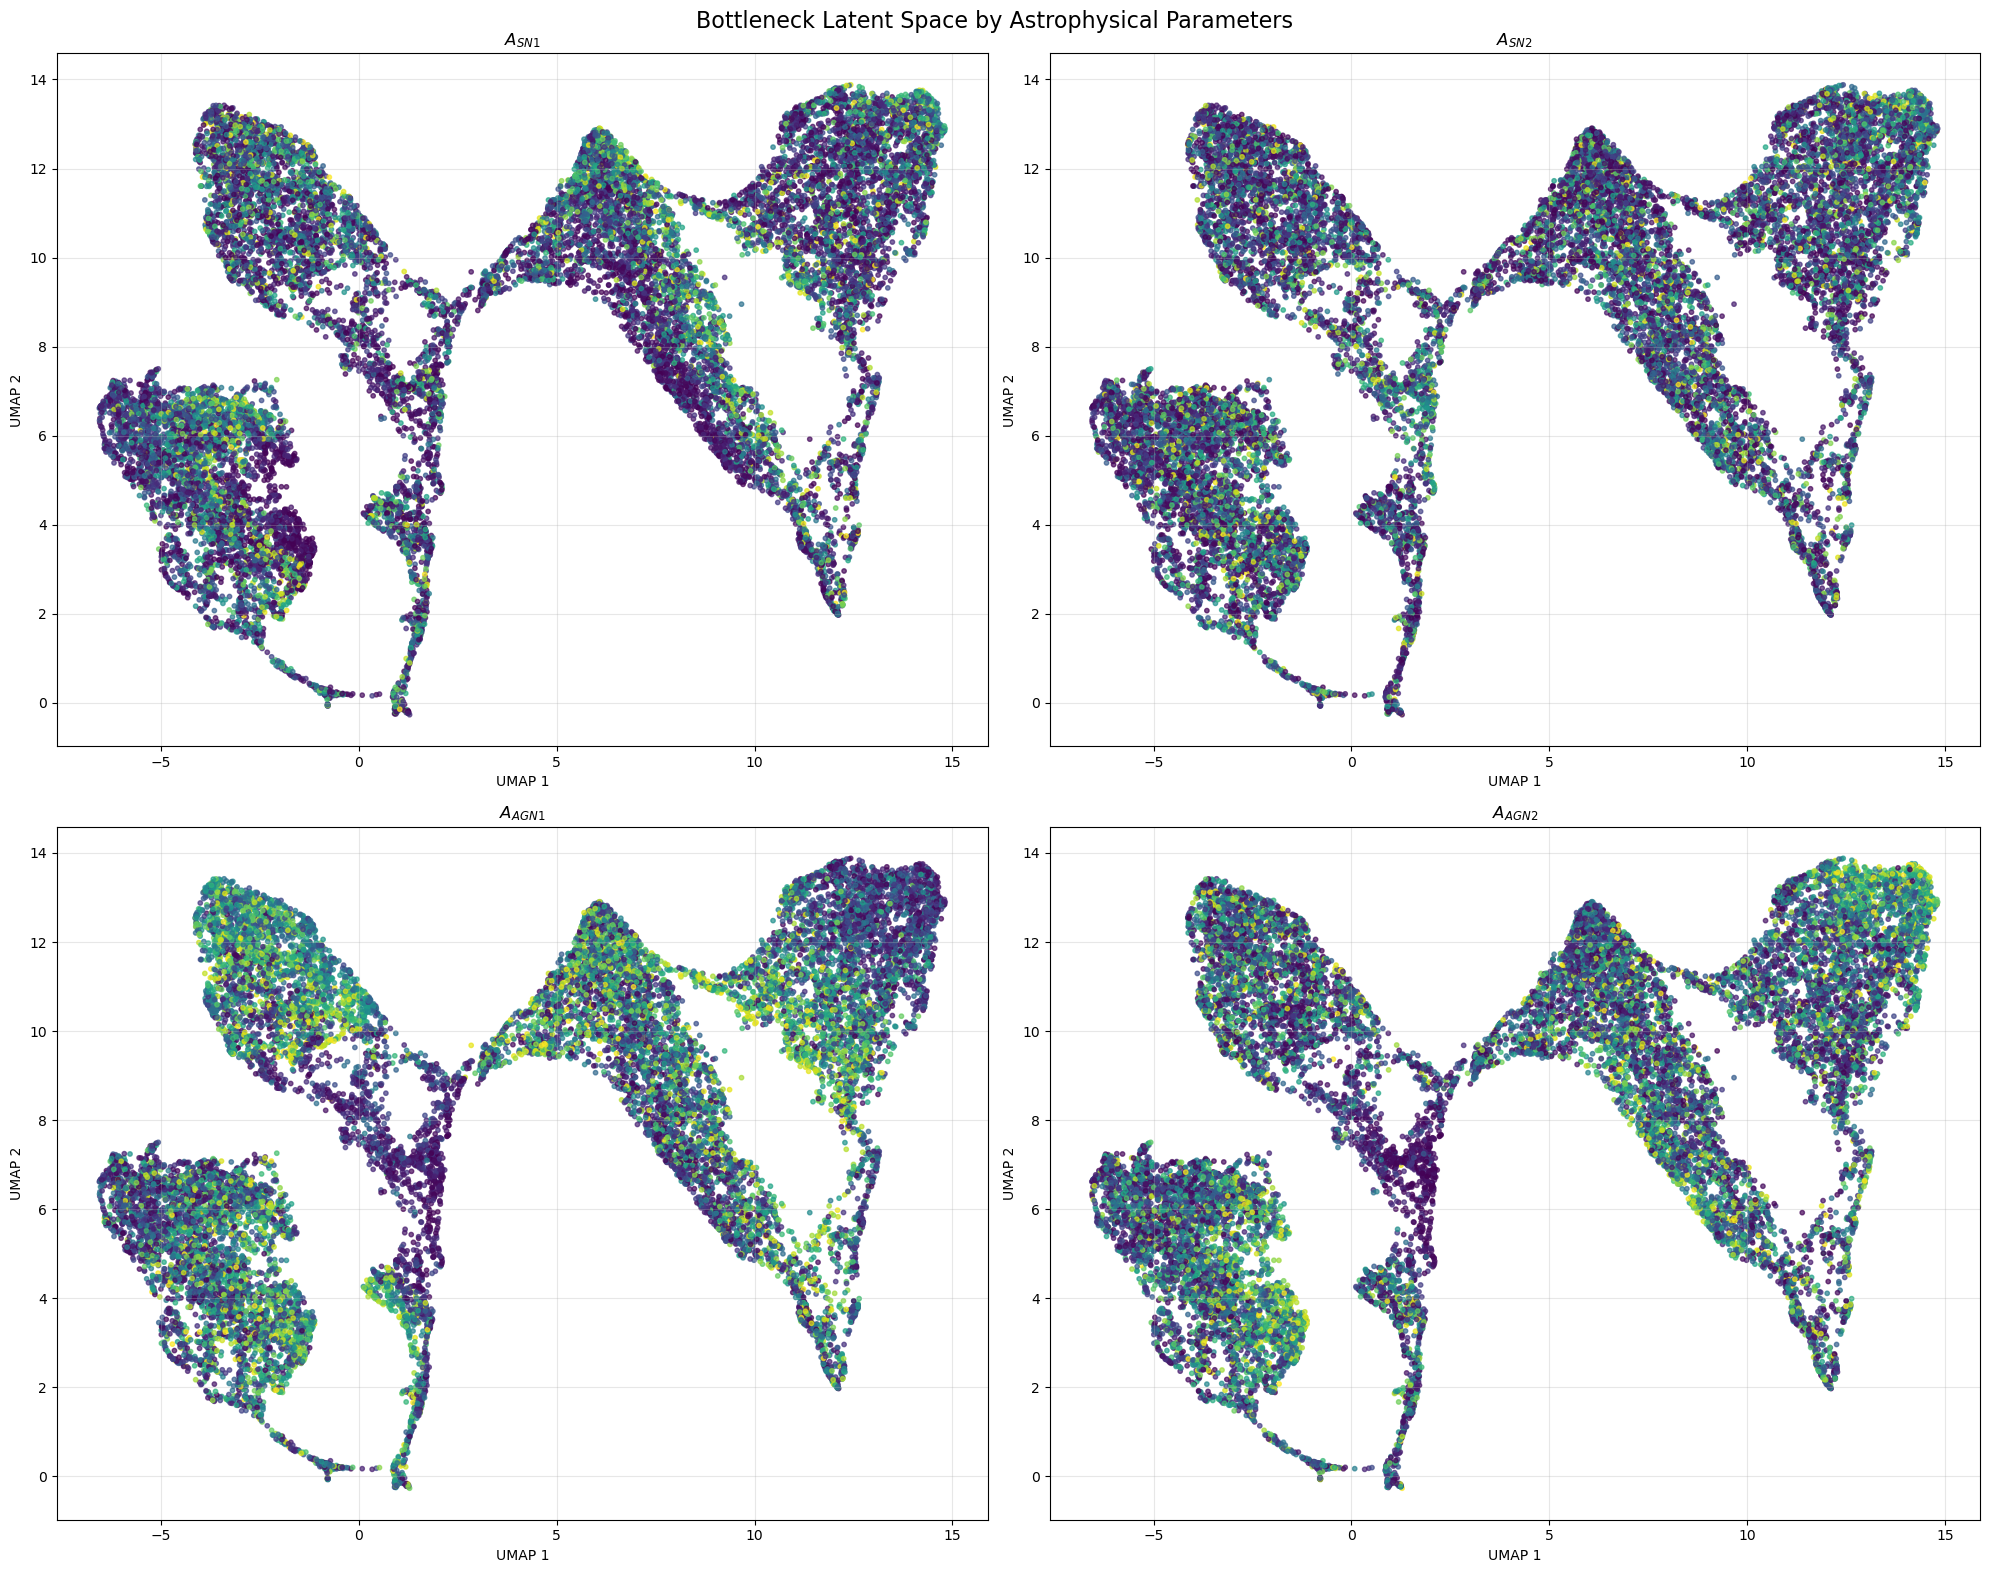

Visualization saved. Total samples: 20000


In [32]:
# Visualize
plt.figure(figsize=(20, 16))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']
titles = ['$A_{SN1}$','$A_{SN2}$','$A_{AGN1}$','$A_{AGN2}$']
all_astro_params = np.asarray(all_astro_params)

for i, title in enumerate(titles):
    plt.subplot(2,2,i+1)

    for j, model_name in enumerate(cosmological_models):
        mask = [label == model_name for label in all_labels]
        plt.scatter(embedding[mask, 0], embedding[mask, 1], 
                   c=all_astro_params[j,:,i], alpha=0.7, s=10)
        
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.grid(True, alpha=0.3)
    plt.title(title)

plt.suptitle('Bottleneck Latent Space by Astrophysical Parameters', fontsize=16)
plt.tight_layout()
plt.savefig("umap_visualization_astro.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization saved. Total samples: {len(embedding)}")


In [34]:
#### ResNet Features ####
class ResNetBottleneckExtractor:
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
        self.model.to(self.device)
        self.model.eval()
        
        self.features = []
        self.model.scalar_field.resnet_branch.avgpool.register_forward_hook(self._hook_fn)
        
    def _hook_fn(self, module, input, output):
        self.features.append(output.view(output.size(0), -1).detach().cpu())
    
    def extract_features(self, total_mass, star_maps, gas_maps, astro_params, batch_size=25):
        all_features = []
        n_samples = len(total_mass)
        
        for i in range(0, n_samples, batch_size):
            self.features = []
            end_idx = min(i + batch_size, n_samples)
            
            # Prepare batch tensors
            total_mass_batch = torch.FloatTensor(total_mass[i:end_idx]).unsqueeze(1).to(self.device)
            target_maps = torch.stack([
                torch.FloatTensor(star_maps[i:end_idx]),
                torch.FloatTensor(gas_maps[i:end_idx])
            ], dim=1).to(self.device)
            
            # Handle astro params
            astro_start = i // 15
            astro_end = min((end_idx + 14) // 15, len(astro_params))
            astro_batch = torch.FloatTensor(astro_params[astro_start:astro_end]).to(self.device)
            
            # Forward pass setup
            batch_sz = total_mass_batch.size(0)
            t = torch.rand(batch_sz, device=self.device)
            
            x0 = total_mass_batch.expand(-1, 2, -1, -1)
            x1 = target_maps
            x_t = (1 - t.view(-1, 1, 1, 1)) * x0 + t.view(-1, 1, 1, 1) * x1
            
            if astro_batch.size(0) != batch_sz:
                repeat_factor = (batch_sz + astro_batch.size(0) - 1) // astro_batch.size(0)
                astro_batch = astro_batch.repeat(repeat_factor, 1)[:batch_sz]
            
            condition_param = torch.cat([t.unsqueeze(1), astro_batch], dim=1)
            
            with torch.no_grad():
                _ = self.model.scalar_field(x_t, condition_param, total_mass_batch, target_maps)
            
            if self.features:
                all_features.append(torch.cat(self.features, dim=0).numpy())
            
            # Clear memory
            del total_mass_batch, target_maps, astro_batch, x_t, condition_param
            torch.cuda.empty_cache()
        
        return np.vstack(all_features) if all_features else np.array([])

Extracting ResNet features...
Processing IllustrisTNG...
Processing EAGLE...
Processing SIMBA...
Processing Astrid...
Total features: (20000, 256)


/n/home02/msliu/.conda/envs/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


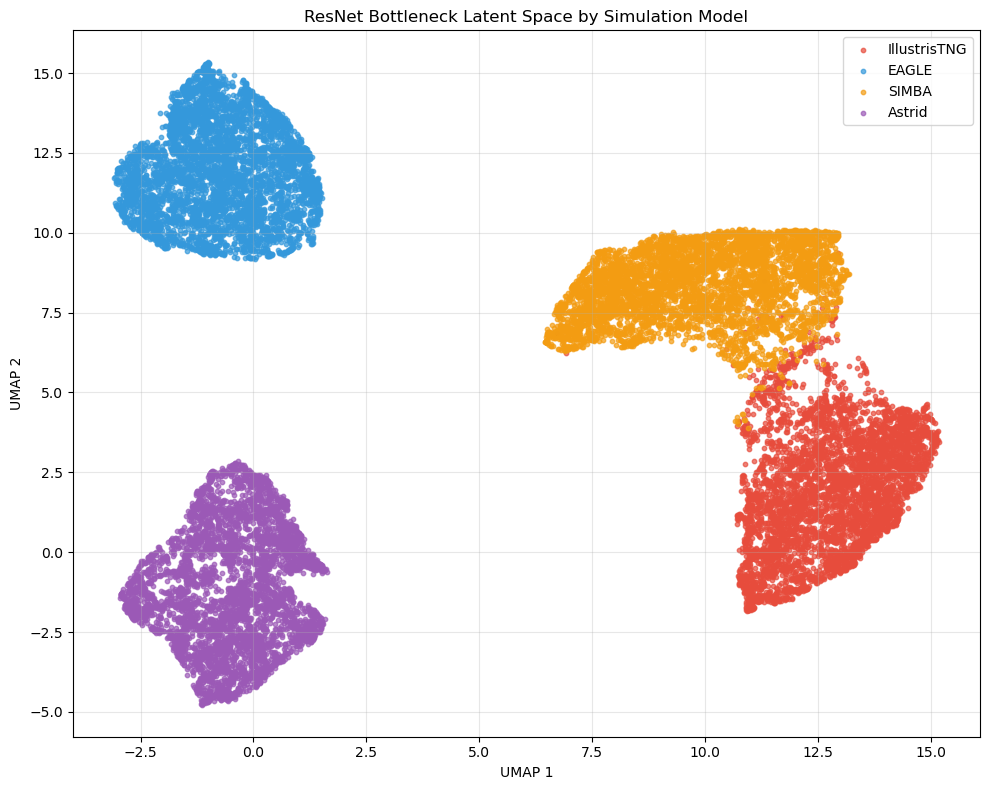

Visualization saved. Total samples: 20000


In [37]:
checkpoint_path = 'lightning_logs/FM_all/checkpoints/best-model-epoch=88-val_loss=0.023915.ckpt'
cosmological_models = ['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid']

print("Extracting ResNet features...")
extractor = ResNetBottleneckExtractor(checkpoint_path)

all_features = []
all_labels = []

for model_name in cosmological_models:
    print(f"Processing {model_name}...")
    total_mass, star_maps, gas_maps, cosmo_params, astro_params = load_model_data(model_name, n_samples=5000)
    features = extractor.extract_features(total_mass, star_maps, gas_maps, cosmo_params)
    
    if len(features) > 0:
        all_features.append(features)
        all_labels.extend([model_name] * len(features))

# UMAP
X = np.vstack(all_features)
print(f"Total features: {X.shape}")

embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)

# Plot
plt.figure(figsize=(10, 8))
colors = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']

for i, model_name in enumerate(cosmological_models):
    mask = [label == model_name for label in all_labels]
    plt.scatter(embedding[mask, 0], embedding[mask, 1], 
               c=colors[i], label=model_name, alpha=0.7, s=10)

plt.title('ResNet Bottleneck Latent Space by Simulation Model')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("resnet_umap_visualisation.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding)}")
